# Distributed Quantum Error Correction via Circuit Cutting

This notebook implements and evaluates a **3-qubit repetition code** emulating distributed quantum error correction (DQEC) using `qiskit-addon-cutting`.

Each of the three data qubits (A, B, C) is assigned to its own virtual QPU partition, and the CNOT gates that cross partition boundaries are **cut** - allowing each subcircuit to run independently. Results are classically reconstructed to recover the full expectation value.

## Notebook Structure

1. [Setup & Backend Configuration](#1.-Setup-&-Backend-Configuration)  
2. [Build Circuits](#2.-Build-the-3-Qubit-Repetition-Code-Circuit)
3. [Error Injection Scenarios](#3.-Error-Injection-Scenarios)
4. [Circuit Cutting & Partitioning](#4.-Circuit-Cutting-&-Partitioning)
5. [Noisy Simulator (FakePoughkeepsieV2 + Aer)](#5.-Run-on-Noisy-Simulator)
6. [Syndrome Measurement & Error Correction](#6.-Syndrome-Measurement)
7. [Real Hardware (ibm_rensselaer)](#7.-Run-on-Real-Hardware-(ibm_rensselaer))
8. [Results Comparison](#8.-Results-Comparison)

---
### Prerequisites
```bash
pip install qiskit qiskit-ibm-runtime qiskit-aer qiskit-addon-cutting
```

## 1. Setup & Backend Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import SparsePauliOp, Statevector, PauliList
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Batch
from qiskit_ibm_runtime.fake_provider import FakePoughkeepsieV2
from qiskit_aer import AerSimulator

from qiskit_addon_cutting import cut_gates, partition_problem, generate_cutting_experiments, reconstruct_expectation_values
from qiskit_addon_cutting.utils.simulation import ExactSampler

print("All imports successful.")

All imports successful.


In [25]:
service = QiskitRuntimeService(name="CSCI4963_poonc3")

# Real hardware backend
real_backend = service.backend("ibm_rensselaer")

# Noisy simulator that mirrors ibm_rensselaer's noise model
noisy_sim = AerSimulator.from_backend(real_backend)

# Fake backend for local noisy runs (models early 20-qubit Poughkeepsie QPU)
fake_backend = FakePoughkeepsieV2()

print(f"Real backend  : {real_backend.name}")
print(f"Noisy sim     : {noisy_sim.name}")
print(f"Fake backend  : {fake_backend.name}")
print(fake_backend.description)

Real backend  : ibm_rensselaer
Noisy sim     : aer_simulator_from(ibm_rensselaer)
Fake backend  : fake_poughkeepsie
20 qubit device Poughkeepsie


## 2. Build the 3-Qubit Repetition Code Circuit

### Qubit layout
| Qubit | Role | QPU partition |
|---|---|---|
| q0 (A) | Data - holds input \|$\psi$⟩ | QPU A |
| q1 (B) | Data - ancilla copy | QPU B |
| q2 (C) | Data - ancilla copy | QPU C |
| q3 | Syndrome ancilla S₀ | QPU A |
| q4 | Syndrome ancilla S₁ | QPU A |

### Encoding
Starting from \|$\psi$⟩ = α\|0⟩ + β\|1⟩ on q0, two CNOTs spread the logical information:

$$|\psi\rangle \xrightarrow{\text{encode}} \alpha|000\rangle_{ABC} + \beta|111\rangle_{ABC}$$

The CNOT q0→q1 and CNOT q0→q2 cross QPU boundaries.

### Syndrome measurement
Two parity checks without collapsing the data qubits:
- **S₀** (q3): compares q0 and q1 → detects disagreement between A and B
- **S₁** (q4): compares q0 and q2 → detects disagreement between A and C

In [3]:
def build_encoding_circuit(alpha = np.pi / 3, phase_flip_mode = False):
    """
    Encoding-only circuit for the 3 data qubits - no ancillae, no measurement.
    This is what gets cut and partitioned across QPUs A, B, C.

    Output: α|000⟩ + β|111⟩  (or α|+++⟩ + β|---⟩ in phase_flip_mode)
    """
    qc = QuantumCircuit(3)

    # State preparation (arbitrary state using Ry gate)
    qc.ry(alpha, 0)
    qc.barrier(label="state_prep")

    # Encoding CNOTs - these are the cross-QPU gates that will be cut
    qc.cx(0, 1)   # QPU A → QPU B  (cut candidate 0)
    qc.cx(0, 2)   # QPU A → QPU C  (cut candidate 1)
    qc.barrier(label="encoded")

    # Phase-flip mode: encode in X basis so Z errors become X errors
    if phase_flip_mode:
        qc.h([0, 1, 2])
    qc.barrier(label="basis")

    return qc


def build_syndrome_circuit(error_type = None, error_qubit = 0, phase_flip_mode = False):
    """
    Standalone syndrome measurement circuit (monolithic, not cut).

    In phase_flip_mode the syndrome CNOTs are sandwiched in H gates
    to measure in the X basis (stabilizers X₁⊗X₂ and X₁⊗X₃).
    """
    qr = QuantumRegister(5, "q")
    cr = ClassicalRegister(2, "syndrome")
    qc = QuantumCircuit(qr, cr)

    # Error injection on the data qubits
    if error_type == "X":
        qc.x(error_qubit)
    elif error_type == "Z":
        qc.z(error_qubit)
    qc.barrier(label="error")

    # Syndrome extraction
    # For phase_flip_mode we need X-basis parity, i.e. stabilizers X₁⊗X₂, X₁⊗X₃.
    # Z-basis CNOTs with H on all data qubits:
    # H⊗H⊗H · (Z-syndrome circuit) · H⊗H⊗H  measures X-parity.
    if phase_flip_mode:
        qc.h([0, 1, 2])
    
    # S0 - parity of q0 and q1 → ancilla q3
    qc.cx(0, 3)
    qc.cx(1, 3)

    # S1 - parity of q0 and q2 → ancilla q4
    qc.cx(0, 4)
    qc.cx(2, 4)

    # restore basis after measurement
    if phase_flip_mode:
        qc.h([0, 1, 2])

    qc.barrier(label="syndrome")

    # Measure only the ancillae - data qubits remain untouched
    qc.measure(3, 0)   # S0 → classical bit 0
    qc.measure(4, 1)   # S1 → classical bit 1

    return qc

── Monolithic circuit (no error) ──


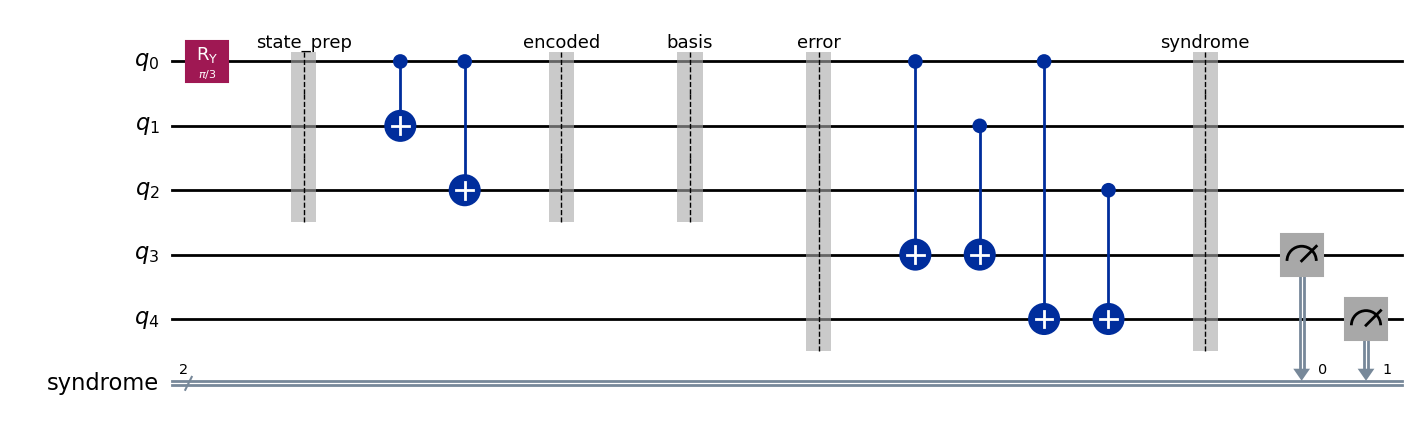

── Monolithic circuit (bit-flip on B) ──


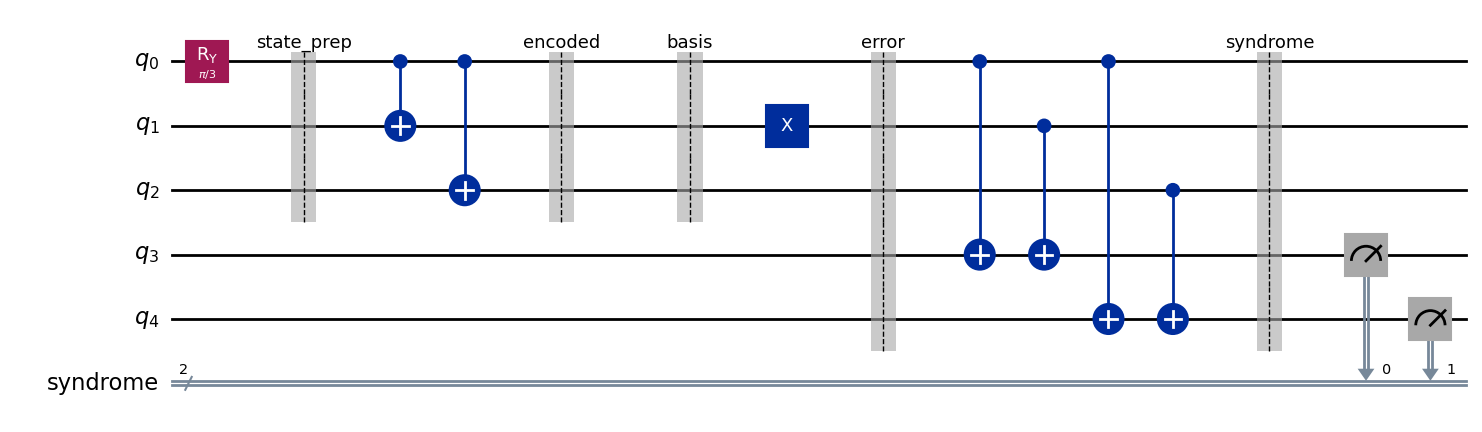

── Monolithic circuit (phase-flip on A) ──


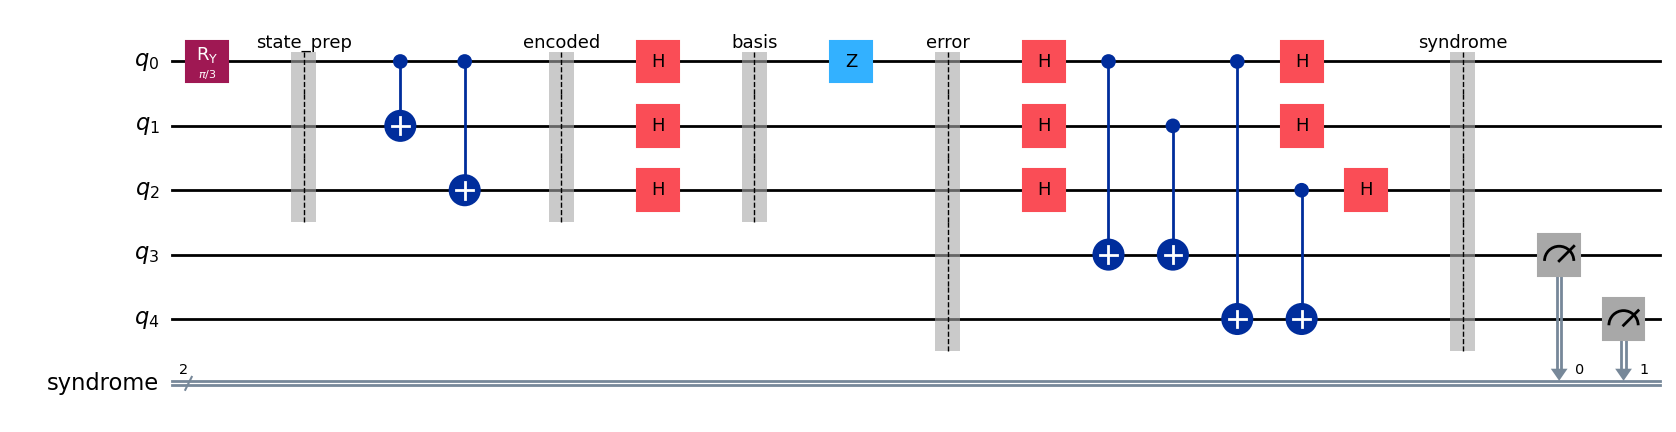

In [4]:
# Monolithic circuit (encoding + error + syndrome)
def build_full_circuit(alpha = np.pi / 3, error_type = None, error_qubit = 0, phase_flip_mode = False):
    """Combine encoding and syndrome into one viewable circuit."""
    enc = build_encoding_circuit(alpha=alpha, phase_flip_mode=phase_flip_mode)

    # Pad encoding to 5 qubits so it can compose with the syndrome circuit
    enc_padded = QuantumCircuit(5)
    enc_padded.compose(enc, qubits=[0, 1, 2], inplace=True)

    syn = build_syndrome_circuit(
        error_type=error_type,
        error_qubit=error_qubit,
        phase_flip_mode=phase_flip_mode,
    )

    return enc_padded.compose(syn, inplace=False)


# Partition
def build_and_cut(alpha = np.pi / 3, phase_flip_mode = False):
    """Return the cut circuit and its per-QPU subcircuits for visualization."""
    enc = build_encoding_circuit(alpha=alpha, phase_flip_mode=phase_flip_mode)

    cx_indices = [
        i for i, instr in enumerate(enc.data)
        if instr.operation.name == "cx"
    ]
    qc_cut, _ = cut_gates(enc, cx_indices[:2])

    # partition_problem requires a PauliList, not a list of SparsePauliOp.
    # Each string must have exactly num_qubits (3) characters.
    # Qiskit Pauli strings are right-to-left: rightmost character = q0.
    observables = PauliList(["IZZ", "ZIZ", "III"])
    #                         ^^^    ^^^
    #  Z on q0+q1 (A vs B)   Z on q0+q2 (A vs C)

    # partition_problem returns a named tuple: (subcircuits, bases, subobservables)
    result = partition_problem(
        circuit=qc_cut,
        partition_labels=["A", "B", "C"],
        observables=observables,
    )
    subcircuits    = result.subcircuits
    subobservables = result.subobservables

    return qc_cut, subcircuits, subobservables


def cut_and_partition(encoding_circuit):
    cx_indices = [
        i for i, instr in enumerate(encoding_circuit.data)
        if instr.operation.name == "cx"
    ]
    assert len(cx_indices) >= 2, "Expected at least 2 encoding CNOTs"
    qc_cut, _bases = cut_gates(encoding_circuit, cx_indices[:2])

    observables = PauliList(["IZZ", "ZIZ", "III"])

    result = partition_problem(
        circuit=qc_cut,
        partition_labels=["A", "B", "C"],
        observables=observables,
    )
    subcircuits    = result.subcircuits
    subobservables = result.subobservables

    subexperiments, coefficients = generate_cutting_experiments(
        circuits=subcircuits,
        observables=subobservables,
        num_samples=np.inf,
    )
    return subcircuits, subobservables, subexperiments, coefficients


# Visualize
ALPHA = np.pi / 3

qc_mono = build_full_circuit(alpha=ALPHA)
print("── Monolithic circuit (no error) ──")
display(qc_mono.draw(output="mpl", fold=-1, style="iqp"))

qc_mono_err = build_full_circuit(alpha=ALPHA, error_type="X", error_qubit=1)
print("── Monolithic circuit (bit-flip on B) ──")
display(qc_mono_err.draw(output="mpl", fold=-1, style="iqp"))

qc_mono_pf = build_full_circuit(alpha=ALPHA, error_type="Z", error_qubit=0, phase_flip_mode=True)
print("── Monolithic circuit (phase-flip on A) ──")
display(qc_mono_pf.draw(output="mpl", fold=-1, style="iqp"))

── Cut encoding circuit (QPDGates marked) ──


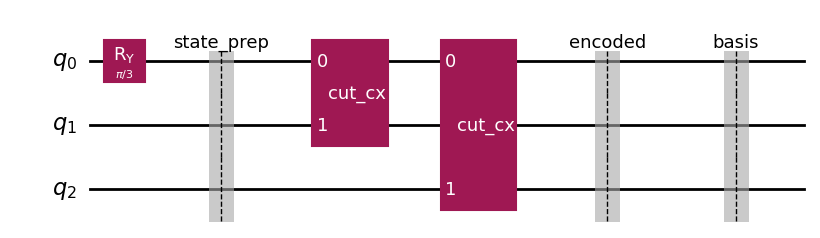

── Per-QPU subcircuits after partitioning ──
  QPU A: 1 qubit(s), depth=1, gates=1


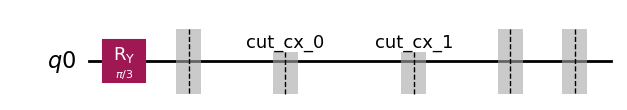

  QPU B: 1 qubit(s), depth=0, gates=0


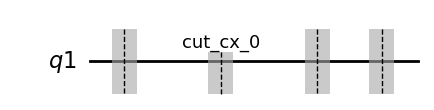

  QPU C: 1 qubit(s), depth=0, gates=0


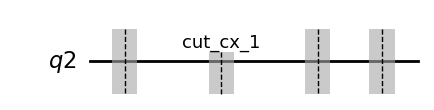

In [5]:
# 4. Cut circuit - shows TwoQubitQPDGates where CNOTs were
qc_cut, subcircuits, subobservables = build_and_cut(alpha=ALPHA)
print("── Cut encoding circuit (QPDGates marked) ──")
display(qc_cut.draw(output="mpl", fold=-1, style="iqp"))

# 5. Per-QPU subcircuits
print("── Per-QPU subcircuits after partitioning ──")
for label, sc in subcircuits.items():
    print(f"  QPU {label}: {sc.num_qubits} qubit(s), depth={sc.depth()}, gates={sc.size()}")
    display(sc.draw(output="mpl", fold=-1, style="iqp"))

## 3. Error Injection Scenarios

We will evaluate all 7 scenarios:

| Scenario | Error | Expected Syndrome |
|---|---|---|
| No error | None | 00 |
| Bit-flip on A | X on q0 | 11 |
| Bit-flip on B | X on q1 | 10 |
| Bit-flip on C | X on q2 | 01 |
| Phase-flip on A | Z on q0 | - (detected in H basis) |
| Phase-flip on B | Z on q1 | - |
| Phase-flip on C | Z on q2 | - |

In [6]:
SCENARIOS = [
    {"error_type": None,  "error_qubit": 0, "phase_flip_mode": False, "label": "No error"},
    {"error_type": "X",   "error_qubit": 0, "phase_flip_mode": False, "label": "Bit-flip A (q0)"},
    {"error_type": "X",   "error_qubit": 1, "phase_flip_mode": False, "label": "Bit-flip B (q1)"},
    {"error_type": "X",   "error_qubit": 2, "phase_flip_mode": False, "label": "Bit-flip C (q2)"},
    {"error_type": "Z",   "error_qubit": 0, "phase_flip_mode": True,  "label": "Phase-flip A (q0)"},
    {"error_type": "Z",   "error_qubit": 1, "phase_flip_mode": True,  "label": "Phase-flip B (q1)"},
    {"error_type": "Z",   "error_qubit": 2, "phase_flip_mode": True,  "label": "Phase-flip C (q2)"},
]

## 4. Circuit Cutting & Partitioning

### Why cut?
The two encoding CNOTs (q0→q1, q0→q2) cross QPU boundaries. In a real distributed system these would be implemented via entanglement; here we **cut** them using the quasi-probability decomposition (QPD) method from `qiskit-addon-cutting`.

### Partition labels
```
q0 → A   (QPU A - Alice: holds input state + ancillae)
q1 → B   (QPU B - Bob)
q2 → C   (QPU C - Charlie)
q3 → A   (QPU A - syndrome ancilla S0)
q4 → A   (QPU A - syndrome ancilla S1)
```

### Observables
- **⟨IZZ⟩** - Z on q0, Z on q1 → parity of A vs B (stabilizer S1, Z basis)
- **⟨ZIZ⟩** - Z on q0, Z on q2 → parity of A vs C (stabilizer S2, Z basis)
- **⟨IXX⟩** - X on q0, X on q1 → parity of A vs B (stabilizer S1, X basis)
- **⟨XIX⟩** - X on q0, X on q2 → parity of A vs C (stabilizer S2, X basis)

Note: Qiskit Pauli strings are written **right-to-left** (q0 is the rightmost character).

In [7]:
# Statevector Verification
# Compare monolithic statevector ground truth against ideal circuit-cut reconstruction.

def build_encoding_with_error(alpha = np.pi / 3, error_type = None, error_qubit = 0, phase_flip_mode = False, 
                              correction = None):
    qc = QuantumCircuit(3)
    qc.ry(alpha, 0)
    qc.barrier(label="state_prep")
    qc.cx(0, 1)
    qc.cx(0, 2)
    qc.barrier(label="encoded")
    if phase_flip_mode:
        qc.h([0, 1, 2])
    qc.barrier(label="basis")
    if error_type == "X":
        qc.x(error_qubit)
    elif error_type == "Z":
        qc.z(error_qubit)
    qc.barrier(label="error")

    # Apply correction gate based on decoded syndrome
    if correction is not None:
        CORRECTION = {
            "11": (0, "X" if not phase_flip_mode else "Z"),
            "10": (1, "X" if not phase_flip_mode else "Z"),
            "01": (2, "X" if not phase_flip_mode else "Z"),
        }
        if correction in CORRECTION:
            qubit, gate = CORRECTION[correction]
            if gate == "X":
                qc.x(qubit)
            elif gate == "Z":
                qc.z(qubit)
        qc.barrier(label="corrected")

    return qc
    
def monolithic_expvals(enc):
    """
    Compute exact expectation values directly from the statevector.
    No cutting - this is the ground truth.
    """
    sv = Statevector(enc)
    obs_list = [SparsePauliOp("IZZ"), SparsePauliOp("ZIZ"), SparsePauliOp("III")]
    return np.array([float(np.real(sv.expectation_value(o))) for o in obs_list])


def run_exact_cutting(enc):
    """
    Run circuit-cut subexperiments with ExactSampler.
    Returns reconstructed expectation values - should match monolithic exactly.
    """
    subcircuits, subobservables, subexperiments, coefficients = cut_and_partition(enc)

    sampler = ExactSampler()
    results = {
        label: sampler.run(partition_subexpts).result()
        for label, partition_subexpts in subexperiments.items()
    }
    return np.real(reconstruct_expectation_values(results, coefficients, subobservables))


print("Statevector vs Ideal Cut - all scenarios")
print(f"{'Scenario':<22} {'⟨ZZI⟩ mono':>12} {'⟨ZZI⟩ cut':>12} {'⟨ZIZ⟩ mono':>12} {'⟨ZIZ⟩ cut':>12} {'Max error':>12}")
print("=" * 85)

mono_results  = {}
ideal_results = {}

for sc in SCENARIOS:
    enc = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
    )
    mono_ev  = monolithic_expvals(enc)
    ideal_ev = run_exact_cutting(enc)

    mono_results[sc["label"]]  = mono_ev
    ideal_results[sc["label"]] = ideal_ev

    max_err = np.max(np.abs(mono_ev - ideal_ev))
    print(
        f"{sc['label']:<22}"
        f"{mono_ev[0]:>+12.6f}{ideal_ev[0]:>+12.6f}"
        f"{mono_ev[1]:>+12.6f}{ideal_ev[1]:>+12.6f}"
        f"{max_err:>12.2e}"
    )

print()
print("Expected ⟨ZZI⟩ and ⟨ZIZ⟩ values:")
print("  No error                :  +1.0,  +1.0  (codeword, all agree in Z basis)")
print("  Bit-flip on A (q0)      :  -1.0,  -1.0  (A disagrees with B and C)")
print("  Bit-flip on B (q1)      :  -1.0,  +1.0  (only A vs B disagrees)")
print("  Bit-flip on C (q2)      :  +1.0,  -1.0  (only A vs C disagrees)")
print("  Phase-flip (any qubit)  :   0.0,   0.0  (X-basis encoding, Z observables")
print("                                            have no parity signal by design)")

Statevector vs Ideal Cut — all scenarios
Scenario                 ⟨ZZI⟩ mono    ⟨ZZI⟩ cut   ⟨ZIZ⟩ mono    ⟨ZIZ⟩ cut    Max error
No error                 +1.000000   +1.000000   +1.000000   +1.000000    7.77e-16
Bit-flip A (q0)          -1.000000   -1.000000   -1.000000   -1.000000    7.77e-16
Bit-flip B (q1)          -1.000000   -1.000000   +1.000000   +1.000000    7.77e-16
Bit-flip C (q2)          +1.000000   +1.000000   -1.000000   -1.000000    7.77e-16
Phase-flip A (q0)        +0.000000   +0.000000   +0.000000   +0.000000    5.55e-16
Phase-flip B (q1)        +0.000000   +0.000000   +0.000000   +0.000000    5.55e-16
Phase-flip C (q2)        +0.000000   +0.000000   +0.000000   +0.000000    5.55e-16

Expected ⟨ZZI⟩ and ⟨ZIZ⟩ values:
  No error                :  +1.0,  +1.0  (codeword, all agree in Z basis)
  Bit-flip on A (q0)      :  -1.0,  -1.0  (A disagrees with B and C)
  Bit-flip on B (q1)      :  -1.0,  +1.0  (only A vs B disagrees)
  Bit-flip on C (q2)      :  +1.0,  -1.0  (onl

In [8]:
# Phase-flip verification using X-basis observables
# Z-basis observables ⟨ZZI⟩ and ⟨ZIZ⟩ have no sensitivity to phase-flip errors because phase-flip scenarios are encoded in the X basis (|+++⟩/|---⟩).
# The correct stabilizers for phase-flip detection are X-basis operators:
#   ⟨XXI⟩ = X on q0, X on q1  →  parity of A vs B in X basis
#   ⟨XIX⟩ = X on q0, X on q2  →  parity of A vs C in X basis
# A phase-flip (Z error) on one qubit flips it between |+⟩ and |−⟩, which is exactly what X⊗X detects.

def cut_and_partition_x_basis(encoding_circuit):
    """
    Same as cut_and_partition but uses X-basis stabilizer observables.
    Used to verify phase-flip error detection.
    """
    cx_indices = [
        i for i, instr in enumerate(encoding_circuit.data)
        if instr.operation.name == "cx"
    ]
    assert len(cx_indices) >= 2, "Expected at least 2 encoding CNOTs"
    qc_cut, _bases = cut_gates(encoding_circuit, cx_indices[:2])

    # X-basis parity observables - right-to-left: q2 q1 q0
    observables = PauliList(["IXX", "XIX", "III"])
    #                         ^^^    ^^^
    #              X on q0+q1       X on q0+q2

    result = partition_problem(
        circuit=qc_cut,
        partition_labels=["A", "B", "C"],
        observables=observables,
    )
    subcircuits    = result.subcircuits
    subobservables = result.subobservables

    subexperiments, coefficients = generate_cutting_experiments(
        circuits=subcircuits,
        observables=subobservables,
        num_samples=np.inf,
    )
    return subcircuits, subobservables, subexperiments, coefficients


def run_exact_cutting_x(enc):
    """
    Run circuit-cut subexperiments with X-basis observables.
    Used for phase-flip scenario verification.
    """
    subcircuits, subobservables, subexperiments, coefficients = cut_and_partition_x_basis(enc)

    sampler = ExactSampler()
    results = {
        label: sampler.run(partition_subexpts).result()
        for label, partition_subexpts in subexperiments.items()
    }
    return np.real(reconstruct_expectation_values(results, coefficients, subobservables))


def monolithic_expvals_x(enc):
    """
    Compute X-basis expectation values directly from the statevector.
    Ground truth for phase-flip verification.
    """
    sv = Statevector(enc)
    obs_list = [SparsePauliOp("IXX"), SparsePauliOp("XIX"), SparsePauliOp("III")]
    return np.array([float(np.real(sv.expectation_value(o))) for o in obs_list])


print("X-basis stabilizer verification - phase-flip scenarios only")
print("⟨XXI⟩ = X on q0+q1 (A vs B in X basis)")
print("⟨XIX⟩ = X on q0+q2 (A vs C in X basis)")
print()
print(f"{'Scenario':<22} {'⟨XXI⟩ mono':>12} {'⟨XXI⟩ cut':>12} {'⟨XIX⟩ mono':>12} {'⟨XIX⟩ cut':>12} {'Max error':>12}")
print("=" * 85)

x_mono_results  = {}
x_ideal_results = {}

for sc in SCENARIOS:
    # X-basis observables only make sense for phase-flip encoded circuits
    # For bit-flip scenarios the state is in Z basis - X observables give 0
    enc = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
    )
    mono_ev  = monolithic_expvals_x(enc)
    ideal_ev = run_exact_cutting_x(enc)

    x_mono_results[sc["label"]]  = mono_ev
    x_ideal_results[sc["label"]] = ideal_ev

    max_err = np.max(np.abs(mono_ev - ideal_ev))
    print(
        f"{sc['label']:<22}"
        f"{mono_ev[0]:>+12.6f}{ideal_ev[0]:>+12.6f}"
        f"{mono_ev[1]:>+12.6f}{ideal_ev[1]:>+12.6f}"
        f"{max_err:>12.2e}"
    )

print()
print("Expected ⟨XXI⟩ and ⟨XIX⟩ values:")
print("  No error (Z basis)      :   0.0,   0.0  (Z-basis encoding, X observables")
print("                                            have no parity signal)")
print("  Bit-flip (Z basis)      :   0.0,   0.0  (same - X obs blind to Z-basis errors)")
print("  Phase-flip on A (q0)    :  -1.0,  -1.0  (A disagrees with B and C in X basis)")
print("  Phase-flip on B (q1)    :  -1.0,  +1.0  (only A vs B disagrees in X basis)")
print("  Phase-flip on C (q2)    :  +1.0,  -1.0  (only A vs C disagrees in X basis)")

X-basis stabilizer verification — phase-flip scenarios only
⟨XXI⟩ = X on q0+q1 (A vs B in X basis)
⟨XIX⟩ = X on q0+q2 (A vs C in X basis)

Scenario                 ⟨XXI⟩ mono    ⟨XXI⟩ cut   ⟨XIX⟩ mono    ⟨XIX⟩ cut    Max error
No error                 +0.000000   +0.000000   +0.000000   +0.000000    1.22e-15
Bit-flip A (q0)          +0.000000   +0.000000   +0.000000   +0.000000    1.22e-15
Bit-flip B (q1)          +0.000000   +0.000000   +0.000000   +0.000000    1.22e-15
Bit-flip C (q2)          +0.000000   +0.000000   +0.000000   +0.000000    1.22e-15
Phase-flip A (q0)        -1.000000   -1.000000   -1.000000   -1.000000    1.22e-15
Phase-flip B (q1)        -1.000000   -1.000000   +1.000000   +1.000000    1.22e-15
Phase-flip C (q2)        +1.000000   +1.000000   -1.000000   -1.000000    1.22e-15

Expected ⟨XXI⟩ and ⟨XIX⟩ values:
  No error (Z basis)      :   0.0,   0.0  (Z-basis encoding, X observables
                                            have no parity signal)
  Bit-flip (Z ba

## 5. Run on Noisy Simulator

We run the cut subexperiments on two noisy backends:

- **FakePoughkeepsieV2** - a lightweight fake backend with a realistic noise model, runs locally without using IBM Quantum credits
- **AerSimulator.from_backend(ibm_rensselaer)** - mirrors the actual noise model of your RPI IBM Quantum System One

Both use `SamplerV2` in `Batch` mode.

In [9]:
## Noisy Simulator
# Run cut subexperiments on FakePoughkeepsieV2 and the Aer noise model
# mirroring ibm_rensselaer. Error is injected inside the encoding circuit
# so the cutting pipeline measures the errored state directly.

def run_noisy_cutting(enc, backend, shots = 8192):
    """
    Run circuit-cut subexperiments on a noisy backend.
    Expects a 3-qubit encoding circuit (with error already injected).
    Transpiles each partition's subexperiments to the backend ISA first.
    """
    subcircuits, subobservables, subexperiments, coefficients = cut_and_partition(enc)

    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    isa_subexperiments = {
        label: pm.run(partition_subexpts)
        for label, partition_subexpts in subexperiments.items()
    }

    results = {}
    with Batch(backend=backend) as batch:
        sampler = SamplerV2(mode=batch)
        jobs = {
            label: sampler.run(subsystem_subexpts, shots=shots)
            for label, subsystem_subexpts in isa_subexperiments.items()
        }
    for label, job in jobs.items():
        results[label] = job.result()

    return np.real(reconstruct_expectation_values(results, coefficients, subobservables))

def run_noisy_cutting_x(enc, backend, shots = 8192):
    """
    Run circuit-cut subexperiments with X-basis observables on a noisy backend.
    Used for phase-flip scenarios.
    """
    subcircuits, subobservables, subexperiments, coefficients = cut_and_partition_x_basis(enc)

    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    isa_subexperiments = {
        label: pm.run(partition_subexpts)
        for label, partition_subexpts in subexperiments.items()
    }

    results = {}
    with Batch(backend=backend) as batch:
        sampler = SamplerV2(mode=batch)
        jobs = {
            label: sampler.run(subsystem_subexpts, shots=shots)
            for label, subsystem_subexpts in isa_subexperiments.items()
        }
    for label, job in jobs.items():
        results[label] = job.result()

    return np.real(reconstruct_expectation_values(results, coefficients, subobservables))


SHOTS = 8192
fake_results   = {}
x_fake_results = {}

print("FakePoughkeepsieV2 vs Ideal Cut - all scenarios")
print(f"{'Scenario':<22} {'⟨S1⟩ ideal':>12} {'⟨S1⟩ fake':>12} {'⟨S2⟩ ideal':>12} {'⟨S2⟩ fake':>12} {'Max Δ':>12}  Basis")
print("=" * 95)

for sc in SCENARIOS:
    enc = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
    )

    if sc["phase_flip_mode"]:
        fake_ev = run_noisy_cutting_x(enc, fake_backend, shots=SHOTS)
        x_fake_results[sc["label"]] = fake_ev
        ideal_s1 = x_ideal_results[sc["label"]][0]
        ideal_s2 = x_ideal_results[sc["label"]][1]
        basis    = "X"
    else:
        fake_ev = run_noisy_cutting(enc, fake_backend, shots=SHOTS)
        fake_results[sc["label"]] = fake_ev
        ideal_s1 = ideal_results[sc["label"]][0]
        ideal_s2 = ideal_results[sc["label"]][1]
        basis    = "Z"

    fake_s1   = fake_ev[0]
    fake_s2   = fake_ev[1]
    max_delta = max(abs(ideal_s1 - fake_s1), abs(ideal_s2 - fake_s2))
    print(
        f"{sc['label']:<22}"
        f"{ideal_s1:>+12.6f}{fake_s1:>+12.6f}"
        f"{ideal_s2:>+12.6f}{fake_s2:>+12.6f}"
        f"{max_delta:>12.2e}  {basis}"
    )

FakePoughkeepsieV2 vs Ideal Cut — all scenarios
Scenario                 ⟨S1⟩ ideal    ⟨S1⟩ fake   ⟨S2⟩ ideal    ⟨S2⟩ fake        Max Δ  Basis
No error                 +1.000000   +0.744516   +1.000000   +0.755344    2.55e-01  Z
Bit-flip A (q0)          -1.000000   -0.713095   -1.000000   -0.706248    2.94e-01  Z
Bit-flip B (q1)          -1.000000   -0.712740   +1.000000   +0.746028    2.87e-01  Z
Bit-flip C (q2)          +1.000000   +0.738378   -1.000000   -0.709859    2.90e-01  Z
Phase-flip A (q0)        -1.000000   -0.710402   -1.000000   -0.701215    2.99e-01  X
Phase-flip B (q1)        -1.000000   -0.686935   +1.000000   +0.706635    3.13e-01  X
Phase-flip C (q2)        +1.000000   +0.744434   -1.000000   -0.674490    3.26e-01  X


In [10]:
# Aer noise model mirroring ibm_rensselaer
# Uses actual gate error rates and T1/T2 times from the RPI backend.
# Bit-flip scenarios use Z-basis observables ⟨ZZI⟩, ⟨ZIZ⟩
# Phase-flip scenarios use X-basis observables ⟨XXI⟩, ⟨XIX⟩

aer_results   = {}
x_aer_results = {}

print("Aer noise model (ibm_rensselaer) vs Ideal Cut - all scenarios")
print(f"{'Scenario':<22} {'⟨S1⟩ ideal':>12} {'⟨S1⟩ aer':>12} {'⟨S2⟩ ideal':>12} {'⟨S2⟩ aer':>12} {'Max Δ':>12}  Basis")
print("=" * 95)

for sc in SCENARIOS:
    enc = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
    )

    if sc["phase_flip_mode"]:
        # Phase-flip: use X-basis observables and x-basis cutting pipeline
        ev        = run_noisy_cutting_x(enc, noisy_sim, shots=SHOTS)
        x_aer_results[sc["label"]] = ev
        ideal_s1  = x_ideal_results[sc["label"]][0]
        ideal_s2  = x_ideal_results[sc["label"]][1]
        basis     = "X"
    else:
        # Bit-flip: use Z-basis observables
        ev        = run_noisy_cutting(enc, noisy_sim, shots=SHOTS)
        aer_results[sc["label"]] = ev
        ideal_s1  = ideal_results[sc["label"]][0]
        ideal_s2  = ideal_results[sc["label"]][1]
        basis     = "Z"

    noisy_s1  = ev[0]
    noisy_s2  = ev[1]
    max_delta = max(abs(ideal_s1 - noisy_s1), abs(ideal_s2 - noisy_s2))
    print(
        f"{sc['label']:<22}"
        f"{ideal_s1:>+12.6f}{noisy_s1:>+12.6f}"
        f"{ideal_s2:>+12.6f}{noisy_s2:>+12.6f}"
        f"{max_delta:>12.2e}  {basis}"
    )

Aer noise model (ibm_rensselaer) vs Ideal Cut — all scenarios
Scenario                 ⟨S1⟩ ideal     ⟨S1⟩ aer   ⟨S2⟩ ideal     ⟨S2⟩ aer        Max Δ  Basis
No error                 +1.000000   +0.934947   +1.000000   +0.948445    6.51e-02  Z
Bit-flip A (q0)          -1.000000   -0.925831   -1.000000   -0.929753    7.42e-02  Z
Bit-flip B (q1)          -1.000000   -0.923640   +1.000000   +0.936664    7.64e-02  Z
Bit-flip C (q2)          +1.000000   +0.918916   -1.000000   -0.925124    8.11e-02  Z
Phase-flip A (q0)        -1.000000   -0.921927   -1.000000   -0.933750    7.81e-02  X
Phase-flip B (q1)        -1.000000   -0.949091   +1.000000   +0.925608    7.44e-02  X
Phase-flip C (q2)        +1.000000   +0.924708   -1.000000   -0.937115    7.53e-02  X


── Cut circuit: No error ──


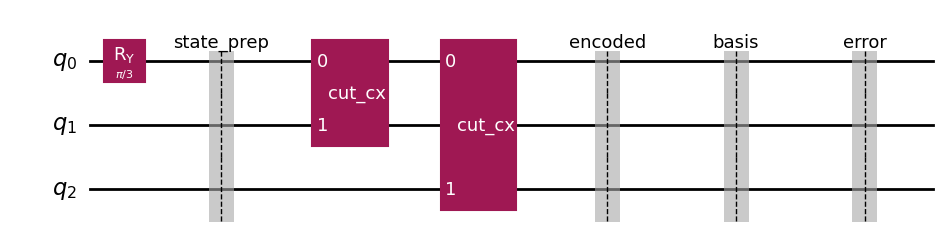

── Cut circuit: Bit-flip on B ──


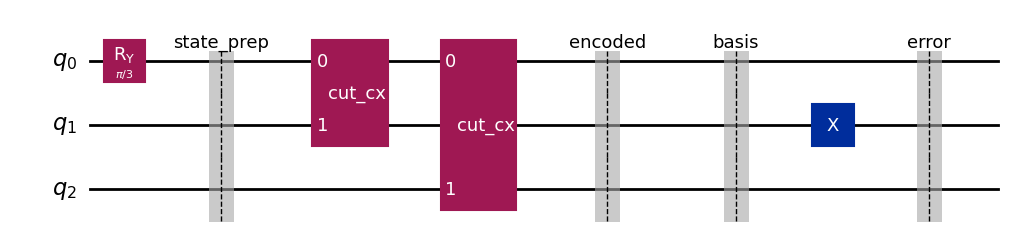

── Cut circuit: Phase-flip on A ──


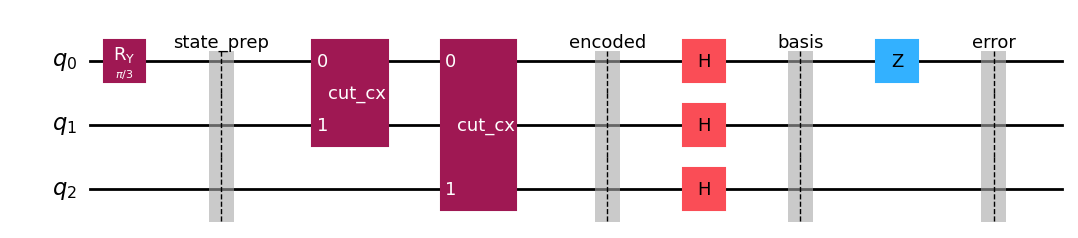

In [11]:
# Visualise the cut circuit for each error type side by side
cut_examples = [
    ("No error",      None, 0, False),
    ("Bit-flip on B", "X",  1, False),
    ("Phase-flip on A", "Z", 0, True),
]

for label, error_type, error_qubit, phase_flip_mode in cut_examples:
    enc = build_encoding_with_error(
        alpha=ALPHA,
        error_type=error_type,
        error_qubit=error_qubit,
        phase_flip_mode=phase_flip_mode,
    )
    cx_indices = [i for i, instr in enumerate(enc.data) if instr.operation.name == "cx"]
    qc_cut, _ = cut_gates(enc, cx_indices[:2])
    print(f"── Cut circuit: {label} ──")
    display(qc_cut.draw(output="mpl", fold=-1, style="iqp"))

## 6. Syndrome Measurement

In [12]:
# Syndrome lookup
SYNDROME_TABLE = {
    "00": "No error",
    "11": "Qubit A (q0) flipped",
    "10": "Qubit B (q1) flipped",
    "01": "Qubit C (q2) flipped",
}

# Expected syndromes for each scenario
EXPECTED_SYNDROMES = {
    "No error"           : "00",
    "Bit-flip A (q0)"    : "11",
    "Bit-flip B (q1)"    : "10",
    "Bit-flip C (q2)"    : "01",
    "Phase-flip A (q0)"  : "11",   # H-basis
    "Phase-flip B (q1)"  : "10",   # H-basis
    "Phase-flip C (q2)"  : "01",   # H-basis
}

# Monolithic baseline
def measure_syndrome(qc, shots=4096):
    sim = AerSimulator(method="statevector")
    job = sim.run(qc, shots=shots)
    counts = job.result().get_counts()
    most_likely = max(counts, key=counts.get).replace(" ", "")
    # Take last 2 characters then reverse so we get S0 S1 order
    raw = most_likely[-2:]   # gives "S1 S0"
    syndrome = raw[::-1]     # reverse to "S0 S1"
    return syndrome, counts

print("Syndrome readout - all scenarios (Aer statevector simulator)")
print(f"{'Scenario':<22} {'Syndrome':>10}   {'Expected':>10}   {'Pass':>6}   Interpretation")
print("=" * 72)

syndrome_results = {}

for sc in SCENARIOS:
    qc = build_full_circuit(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
    )
    syndrome, _ = measure_syndrome(qc)
    expected     = EXPECTED_SYNDROMES[sc["label"]]
    passed       = "✓" if syndrome == expected else "✗"
    syndrome_results[sc["label"]] = syndrome
    interp = SYNDROME_TABLE.get(syndrome, "N/A")
    print(f"{sc['label']:<22} {syndrome:>10}   {expected:>10}   {passed:>6}   {interp}")

Syndrome readout — all scenarios (Aer statevector simulator)
Scenario                 Syndrome     Expected     Pass   Interpretation
No error                       00           00        ✓   No error
Bit-flip A (q0)                11           11        ✓   Qubit A (q0) flipped
Bit-flip B (q1)                10           10        ✓   Qubit B (q1) flipped
Bit-flip C (q2)                01           01        ✓   Qubit C (q2) flipped
Phase-flip A (q0)              11           11        ✓   Qubit A (q0) flipped
Phase-flip B (q1)              10           10        ✓   Qubit B (q1) flipped
Phase-flip C (q2)              01           01        ✓   Qubit C (q2) flipped


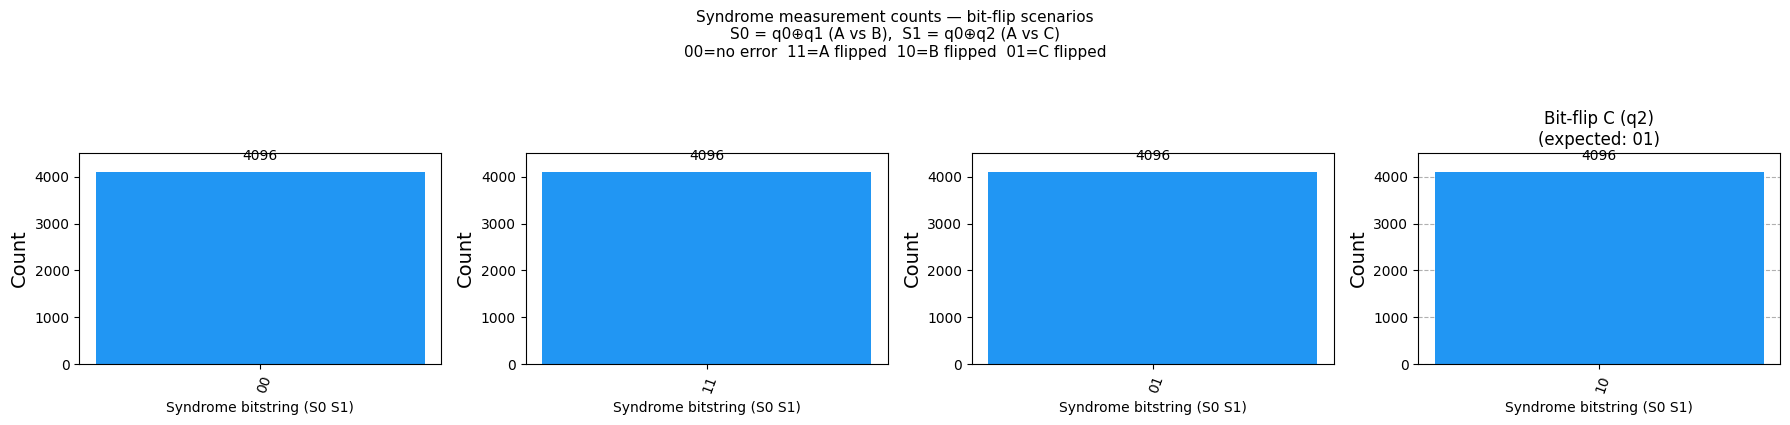

In [13]:
# Syndrome measurement counts, bit-flip scenarios

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bit_flip_scenarios = [sc for sc in SCENARIOS if sc["phase_flip_mode"] is False]

for ax, sc in zip(axes, bit_flip_scenarios):
    qc = build_full_circuit(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=False,
    )
    _, counts = measure_syndrome(qc, shots=4096)
    expected = EXPECTED_SYNDROMES[sc["label"]]
    plot_histogram(
        counts,
        ax=ax,
        title=f"{sc['label']}\n(expected: {expected})",
        color="#2196F3",
    )
    ax.set_xlabel("Syndrome bitstring (S0 S1)")

plt.suptitle(
    "Syndrome measurement counts - bit-flip scenarios\n"
    "S0 = q0⊕q1 (A vs B),  S1 = q0⊕q2 (A vs C)\n"
    "00=no error  11=A flipped  10=B flipped  01=C flipped",
    fontsize=11,
    y=1.05,
)
plt.tight_layout()
plt.show()

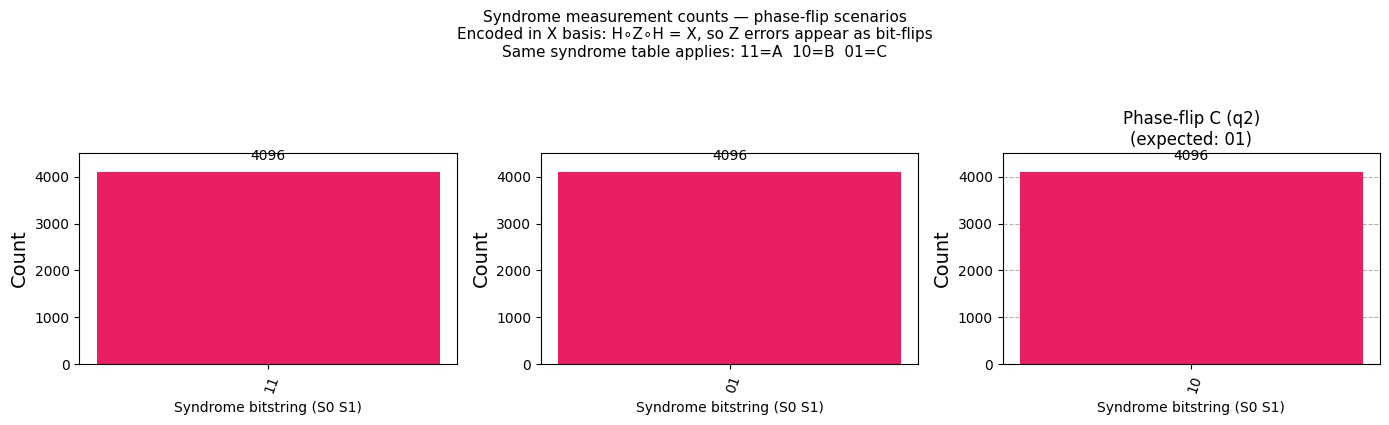

In [14]:
# Syndrome measurement counts, phase-flip scenarios

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

phase_flip_scenarios = [sc for sc in SCENARIOS if sc["phase_flip_mode"] is True]

for ax, sc in zip(axes, phase_flip_scenarios):
    qc = build_full_circuit(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=True,
    )
    _, counts = measure_syndrome(qc, shots=4096)
    expected = EXPECTED_SYNDROMES[sc["label"]]
    plot_histogram(
        counts,
        ax=ax,
        title=f"{sc['label']}\n(expected: {expected})",
        color="#E91E63",
    )
    ax.set_xlabel("Syndrome bitstring (S0 S1)")

plt.suptitle(
    "Syndrome measurement counts - phase-flip scenarios\n"
    "Encoded in X basis: H∘Z∘H = X, so Z errors appear as bit-flips\n"
    "Same syndrome table applies: 11=A  10=B  01=C",
    fontsize=11,
    y=1.05,
)
plt.tight_layout()
plt.show()

In [15]:
def decode_syndrome(zzi, ziz):
    s0 = "1" if zzi < 0 else "0"
    s1 = "1" if ziz < 0 else "0"
    return s0 + s1

print("Distributed syndrome decoding - ideal cut vs noisy backends")
print(f"{'Scenario':<22} {'Expected':>10} {'Ideal':>8} {'Fake':>8} {'Aer':>8}   Fake OK   Aer OK")
print("=" * 75)

for sc in SCENARIOS:
    lbl      = sc["label"]
    expected = EXPECTED_SYNDROMES[lbl]

    if sc["phase_flip_mode"]:
        ideal_syn = decode_syndrome(x_ideal_results[lbl][0], x_ideal_results[lbl][1])
        fake_syn  = decode_syndrome(x_fake_results[lbl][0],  x_fake_results[lbl][1])
        aer_syn   = decode_syndrome(x_aer_results[lbl][0],   x_aer_results[lbl][1])
    else:
        ideal_syn = decode_syndrome(ideal_results[lbl][0], ideal_results[lbl][1])
        fake_syn  = decode_syndrome(fake_results[lbl][0],  fake_results[lbl][1])
        aer_syn   = decode_syndrome(aer_results[lbl][0],   aer_results[lbl][1])

    fake_ok = "✓" if fake_syn == expected else "✗"
    aer_ok  = "✓" if aer_syn  == expected else "✗"
    print(f"{lbl:<22} {expected:>10} {ideal_syn:>8} {fake_syn:>8} {aer_syn:>8}   {fake_ok:>7}   {aer_ok:>5}")

Distributed syndrome decoding — ideal cut vs noisy backends
Scenario                 Expected    Ideal     Fake      Aer   Fake OK   Aer OK
No error                       00       00       00       00         ✓       ✓
Bit-flip A (q0)                11       11       11       11         ✓       ✓
Bit-flip B (q1)                10       10       10       10         ✓       ✓
Bit-flip C (q2)                01       01       01       01         ✓       ✓
Phase-flip A (q0)              11       11       11       11         ✓       ✓
Phase-flip B (q1)              10       10       10       10         ✓       ✓
Phase-flip C (q2)              01       01       01       01         ✓       ✓


In [16]:
## Error Correction Verification
# Decode syndrome from cutting pipeline, apply correction, verify stabilizer syndrome returns to +1
# Tested across ideal, FakePoughkeepsieV2, and Aer noise model backends.

print("Error correction verification - all backends")
print(f"{'Scenario':<22}{'Syndrome':>10}{'Before':>14}{'Ideal':>14}{'Fake':>14}{'Aer':>14}{'Ideal':>8}{'Fake':>8}{'Aer':>8}")
print("=" * 112)

for sc in SCENARIOS:
    lbl = sc["label"]

    # S1 before correction from already-computed results
    if sc["phase_flip_mode"]:
        s1_before = x_ideal_results[lbl][0]
        s2_before = x_ideal_results[lbl][1]
    else:
        s1_before = ideal_results[lbl][0]
        s2_before = ideal_results[lbl][1]

    syndrome = decode_syndrome(s1_before, s2_before)

    # Build corrected circuit
    enc_corrected = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
        correction=syndrome,
    )

    # Run corrected circuit on all three backends
    if sc["phase_flip_mode"]:
        ideal_after = run_exact_cutting_x(enc_corrected)[0]
        fake_after  = run_noisy_cutting_x(enc_corrected, fake_backend,  shots=SHOTS)[0]
        aer_after   = run_noisy_cutting_x(enc_corrected, noisy_sim,     shots=SHOTS)[0]
    else:
        ideal_after = run_exact_cutting(enc_corrected)[0]
        fake_after  = run_noisy_cutting(enc_corrected, fake_backend,  shots=SHOTS)[0]
        aer_after   = run_noisy_cutting(enc_corrected, noisy_sim,     shots=SHOTS)[0]

    ideal_ok = "✓" if abs(ideal_after - 1.0) < 0.01 else "✗"
    fake_ok  = "✓" if abs(fake_after  - 1.0) < 0.1  else "✗"
    aer_ok   = "✓" if abs(aer_after   - 1.0) < 0.1  else "✗"

    print(
        f"{lbl:<22}"
        f"{syndrome:>10}"
        f"{s1_before:>+14.4f}"
        f"{ideal_after:>+14.4f}"
        f"{fake_after:>+14.4f}"
        f"{aer_after:>+14.4f}"
        f"{ideal_ok:>8}{fake_ok:>8}{aer_ok:>8}"
    )

print()
print("Before   = ⟨S1⟩ with error, before correction")
print("Ideal    = ⟨S1⟩ after correction, ExactSampler (no noise)")
print("Fake     = ⟨S1⟩ after correction, FakePoughkeepsieV2")
print("Aer      = ⟨S1⟩ after correction, ibm_rensselaer noise model")
print()
print("Ideal threshold: |⟨S1⟩ - 1.0| < 0.01")
print("Noisy threshold: |⟨S1⟩ - 1.0| < 0.10  (wider tolerance for hardware noise)")

Error correction verification — all backends
Scenario                Syndrome        Before         Ideal          Fake           Aer   Ideal    Fake     Aer
No error                      00       +1.0000       +1.0000       +0.7357       +0.9293       ✓       ✗       ✓
Bit-flip A (q0)               11       -1.0000       +1.0000       +0.7331       +0.9176       ✓       ✗       ✓
Bit-flip B (q1)               10       -1.0000       +1.0000       +0.7376       +0.9349       ✓       ✗       ✓
Bit-flip C (q2)               01       +1.0000       +1.0000       +0.7676       +0.9399       ✓       ✗       ✓
Phase-flip A (q0)             11       -1.0000       +1.0000       +0.7262       +0.9422       ✓       ✗       ✓
Phase-flip B (q1)             10       -1.0000       +1.0000       +0.7425       +0.9160       ✓       ✗       ✓
Phase-flip C (q2)             01       +1.0000       +1.0000       +0.7201       +0.9372       ✓       ✗       ✓

Before   = ⟨S1⟩ with error, before correction
Idea

## 7. Run on Real Hardware (ibm_rensselaer)

In [17]:
HARDWARE_SHOTS = 8192
hardware_results   = {}
x_hardware_results = {}
hardware_corrected_results   = {}
x_hardware_corrected_results = {}
pm_real = generate_preset_pass_manager(optimization_level=1, backend=real_backend)

print("Real hardware (ibm_rensselaer) - errored and corrected")
print(f"{'Scenario':<22}  {'Err ⟨S1⟩':>10}  {'Err ⟨S2⟩':>10}  {'Cor ⟨S1⟩':>10}  {'Cor ⟨S2⟩':>10}  Basis")
print("=" * 80)

for sc in SCENARIOS:
    lbl = sc["label"]

    # Circuit with errors
    enc = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
    )

    if sc["phase_flip_mode"]:
        subcircuits, subobservables, subexperiments, coefficients = cut_and_partition_x_basis(enc)
    else:
        subcircuits, subobservables, subexperiments, coefficients = cut_and_partition(enc)

    isa_subexperiments = {
        label: pm_real.run(partition_subexpts)
        for label, partition_subexpts in subexperiments.items()
    }
    results = {}
    with Batch(backend=real_backend) as batch:
        sampler = SamplerV2(mode=batch)
        jobs = {
            label: sampler.run(subsystem_subexpts, shots=HARDWARE_SHOTS)
            for label, subsystem_subexpts in isa_subexperiments.items()
        }
    for label, job in jobs.items():
        results[label] = job.result()

    hw_ev = np.real(reconstruct_expectation_values(results, coefficients, subobservables))
    if sc["phase_flip_mode"]:
        x_hardware_results[lbl] = hw_ev
    else:
        hardware_results[lbl] = hw_ev

    # Correction circuit
    # Decode syndrome from ideal results (not hardware - syndrome decoding
    # is classical post-processing, no extra hardware shots needed)
    if sc["phase_flip_mode"]:
        s1 = x_hardware_results[lbl][0]
        s2 = x_hardware_results[lbl][1]
    else:
        s1 = hardware_results[lbl][0]
        s2 = hardware_results[lbl][1]

    syndrome = decode_syndrome(s1, s2)

    enc_corrected = build_encoding_with_error(
        alpha=ALPHA,
        error_type=sc["error_type"],
        error_qubit=sc["error_qubit"],
        phase_flip_mode=sc["phase_flip_mode"],
        correction=syndrome,
    )

    if sc["phase_flip_mode"]:
        sub_c, subobs_c, subexp_c, coeff_c = cut_and_partition_x_basis(enc_corrected)
    else:
        sub_c, subobs_c, subexp_c, coeff_c = cut_and_partition(enc_corrected)

    isa_corrected = {
        label: pm_real.run(partition_subexpts)
        for label, partition_subexpts in subexp_c.items()
    }
    results_c = {}
    with Batch(backend=real_backend) as batch:
        sampler = SamplerV2(mode=batch)
        jobs_c = {
            label: sampler.run(subsystem_subexpts, shots=HARDWARE_SHOTS)
            for label, subsystem_subexpts in isa_corrected.items()
        }
    for label, job in jobs_c.items():
        results_c[label] = job.result()

    hw_ev_c = np.real(reconstruct_expectation_values(results_c, coeff_c, subobs_c))
    if sc["phase_flip_mode"]:
        x_hardware_corrected_results[lbl] = hw_ev_c
    else:
        hardware_corrected_results[lbl] = hw_ev_c

    basis = "X" if sc["phase_flip_mode"] else "Z"
    print(
        f"{lbl:<22}"
        f"  errored  ⟨S1⟩={hw_ev[0]:+.4f}  ⟨S2⟩={hw_ev[1]:+.4f}"
        f"  corrected  ⟨S1⟩={hw_ev_c[0]:+.4f}  ⟨S2⟩={hw_ev_c[1]:+.4f}"
        f"  basis={basis}"
    )

Real hardware (ibm_rensselaer) — errored and corrected
Scenario                  Err ⟨S1⟩    Err ⟨S2⟩    Cor ⟨S1⟩    Cor ⟨S2⟩  Basis
No error                errored  ⟨S1⟩=+0.9741  ⟨S2⟩=+0.9725  corrected  ⟨S1⟩=+0.9670  ⟨S2⟩=+0.9683  basis=Z
Bit-flip A (q0)         errored  ⟨S1⟩=-0.9609  ⟨S2⟩=-0.9582  corrected  ⟨S1⟩=+0.9677  ⟨S2⟩=+0.9464  basis=Z
Bit-flip B (q1)         errored  ⟨S1⟩=-0.9660  ⟨S2⟩=+0.9547  corrected  ⟨S1⟩=+0.9559  ⟨S2⟩=+0.9495  basis=Z
Bit-flip C (q2)         errored  ⟨S1⟩=+0.9553  ⟨S2⟩=-0.9557  corrected  ⟨S1⟩=+0.9460  ⟨S2⟩=+0.9693  basis=Z
Phase-flip A (q0)       errored  ⟨S1⟩=-0.9510  ⟨S2⟩=-0.9547  corrected  ⟨S1⟩=+0.9345  ⟨S2⟩=+0.9402  basis=X
Phase-flip B (q1)       errored  ⟨S1⟩=-0.9613  ⟨S2⟩=+0.9550  corrected  ⟨S1⟩=+0.9623  ⟨S2⟩=+0.9609  basis=X
Phase-flip C (q2)       errored  ⟨S1⟩=+0.9690  ⟨S2⟩=-0.9519  corrected  ⟨S1⟩=+0.9447  ⟨S2⟩=+0.9437  basis=X


## 8. Results Comparison

We compare ⟨S1⟩ (the S₁ stabilizer parity check) across three backends:
- **Monolithic** (Statevector) - true ground truth, no cutting
- **Ideal cut** (ExactSampler) - cutting with no noise
- **Noisy (Aer)** - cutting with ibm_rensselaer noise model
- **Fake backend** (FakePoughkeepsieV2) - cutting with generic noise
- **Real backend** (ibm_rensselaer)

Expected behaviour of ⟨ZZI⟩:
- **+1** → q0 and q1 agree (no relative flip between A and B)
- **−1** → q0 and q1 disagree (one of A or B was flipped)

In [18]:
print("=" * 85)
print(f"  {'Scenario':<22} {'Mono':>9} {'Ideal Cut':>11} {'Aer Noisy':>11} {'Fake':>9} {'Aer Δ':>9}  Basis")
print("=" * 85)

for sc in SCENARIOS:
    lbl = sc["label"]

    if sc["phase_flip_mode"]:
        # Phase-flip - use X-basis stabilizer S1 = ⟨XXI⟩
        mono  = x_mono_results[lbl][0]
        ideal = x_ideal_results[lbl][0]
        aer   = x_aer_results[lbl][0]
        fake  = x_fake_results[lbl][0]
        basis = "X"
    else:
        # Bit-flip - use Z-basis stabilizer S1 = ⟨ZZI⟩
        mono  = mono_results[lbl][0]
        ideal = ideal_results[lbl][0]
        aer   = aer_results[lbl][0]
        fake  = fake_results[lbl][0]
        basis = "Z"

    delta = abs(mono - aer)
    print(f"  {lbl:<22} {mono:>+9.4f} {ideal:>+11.4f} {aer:>+11.4f} {fake:>+9.4f} {delta:>9.4f}  {basis}")

print("=" * 85)
print()
print("⟨S1⟩ = +1 → A and B agree   ⟨S1⟩ = −1 → A and B disagree")
print("Z basis for bit-flip scenarios,  X basis for phase-flip scenarios")

  Scenario                    Mono   Ideal Cut   Aer Noisy      Fake     Aer Δ  Basis
  No error                 +1.0000     +1.0000     +0.9349   +0.7445    0.0651  Z
  Bit-flip A (q0)          -1.0000     -1.0000     -0.9258   -0.7131    0.0742  Z
  Bit-flip B (q1)          -1.0000     -1.0000     -0.9236   -0.7127    0.0764  Z
  Bit-flip C (q2)          +1.0000     +1.0000     +0.9189   +0.7384    0.0811  Z
  Phase-flip A (q0)        -1.0000     -1.0000     -0.9219   -0.7104    0.0781  X
  Phase-flip B (q1)        -1.0000     -1.0000     -0.9491   -0.6869    0.0509  X
  Phase-flip C (q2)        +1.0000     +1.0000     +0.9247   +0.7444    0.0753  X

⟨S1⟩ = +1 → A and B agree   ⟨S1⟩ = −1 → A and B disagree
Z basis for bit-flip scenarios,  X basis for phase-flip scenarios


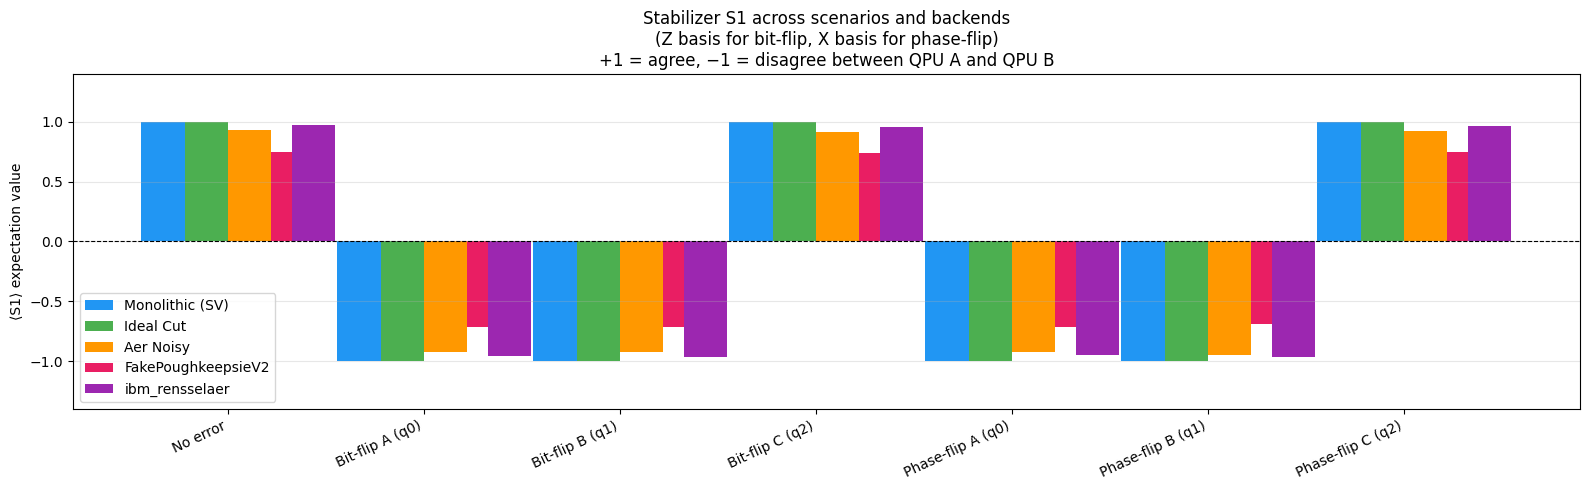

In [24]:
labels     = [sc["label"] for sc in SCENARIOS]
x          = np.arange(len(labels))
width      = 0.22

# Pull S1 value from correct basis per scenario
def get_s1(results_z, results_x, sc):
    lbl = sc["label"]
    return results_x[lbl][0] if sc["phase_flip_mode"] else results_z[lbl][0]

mono_vals  = [get_s1(mono_results,  x_mono_results,  sc) for sc in SCENARIOS]
ideal_vals = [get_s1(ideal_results, x_ideal_results, sc) for sc in SCENARIOS]
aer_vals   = [get_s1(aer_results,   x_aer_results,   sc) for sc in SCENARIOS]
fake_vals  = [get_s1(fake_results,  x_fake_results,  sc) for sc in SCENARIOS]
hardware_vals = [get_s1(hardware_results, x_hardware_results, sc) for sc in SCENARIOS]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - 1.5*width, mono_vals,  width, label="Monolithic (SV)", color="#2196F3")
ax.bar(x - 0.5*width, ideal_vals, width, label="Ideal Cut",        color="#4CAF50")
ax.bar(x + 0.5*width, aer_vals,   width, label="Aer Noisy",        color="#FF9800")
ax.bar(x + 1.5*width, fake_vals,  width, label="FakePoughkeepsieV2", color="#E91E63")
ax.bar(x + 2*width,   hardware_vals, width, label="ibm_rensselaer", color="#9C27B0")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("⟨S1⟩ expectation value")
ax.set_title(
    "Stabilizer S1 across scenarios and backends\n"
    "(Z basis for bit-flip, X basis for phase-flip)\n"
    "+1 = agree, −1 = disagree between QPU A and QPU B"
)
ax.legend()
ax.set_ylim(-1.4, 1.4)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()